---
## SECTION 1 — DATA EXTRACTION VIA API

In [ ]:
import requests
import pandas as pd

API_KEY = "API KEY"   # keep it in quotes
RESOURCE_ID = "98e76922-ab13-474e-9bce-78942583cd0e"

url = (
    f"https://api.data.gov.in/resource/98e76922-ab13-474e-9bce-78942583cd0e"
    f"?api-key=API KEY"
    f"&format=json"
    f"&limit=10000"
)

try:
    response = requests.get(url)
    response.raise_for_status()  # Raise an exception for HTTP errors
    records = response.json().get("records", [])

    df = pd.DataFrame(records)

    df.to_csv("voice_call_quality_data.csv", index=False)

    print("Download completed successfully!")
except requests.exceptions.HTTPError as errh:
    print(f"HTTP Error: {errh}")
    print(f"Response content: {response.text}")
except requests.exceptions.ConnectionError as errc:
    print(f"Error Connecting: {errc}")
except requests.exceptions.Timeout as errt:
    print(f"Timeout Error: {errt}")
except requests.exceptions.RequestException as err:
    print(f"An Unexpected Error occurred: {err}")
    if response is not None:
        print(f"Response content: {response.text}")
except ValueError as e: # Catches JSONDecodeError which inherits from ValueError
    print(f"JSON Decode Error: {e}")
    if response is not None:
        print(f"Response content that caused the error: {response.text}")

Download completed successfully!


---
## SECTION 2 — UNDERSTANDING THE DATASET

In [ ]:
df

,inout_travelling,operator,network_type,rating,calldrop_category,latitude,longitude,state_name,month,year
0,Travelling,jio,4G,3,Poor Voice Quality,19.2422731,72.859278,Maharashtra,9,2017
1,Indoor,jio,4G,3,Satisfactory,27.65794281,94.7122816,Assam,9,2017
2,Outdoor,bsnl,3G,4,Satisfactory,13.08241874,80.20879819,Tamil Nadu,9,2017
3,Indoor,NA,Unknown,2,Call Dropped,15.4729746,73.8098152,Goa,9,2017
4,Indoor,jio,4G,5,Satisfactory,18.6531147,73.8354737,Maharashtra,9,2017
...,...,...,...,...,...,...,...,...,...,...
9995,Indoor,jio,4G,5,Satisfactory,28.71483026,77.21475775,NCT,9,2017
9996,Indoor,airtel,3G,5,Satisfactory,22.55113822,88.35212306,West Bengal,9,2017
9997,Indoor,airtel,Unknown,1,Poor Voice Quality,15.87761232,77.94056439,Telangana,9,2017
9998,Indoor,airtel,4G,5,Satisfactory,18.06602706,79.22891639,Telangana,9,2017


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   inout_travelling   10000 non-null  object
 1   operator           10000 non-null  object
 2   network_type       10000 non-null  object
 3   rating             10000 non-null  object
 4   calldrop_category  10000 non-null  object
 5   latitude           10000 non-null  object
 6   longitude          10000 non-null  object
 7   state_name         10000 non-null  object
 8   month              10000 non-null  int64 
 9   year               10000 non-null  int64 
dtypes: int64(2), object(8)
memory usage: 781.4+ KB


In [ ]:
df.size

100000

In [ ]:
df.describe()

,month,year
count,10000.0,10000.0
mean,9.0,2017.0
std,0.0,0.0
min,9.0,2017.0
25%,9.0,2017.0
50%,9.0,2017.0
75%,9.0,2017.0
max,9.0,2017.0


In [ ]:
df.head()

,inout_travelling,operator,network_type,rating,calldrop_category,latitude,longitude,state_name,month,year
0,Travelling,jio,4G,3,Poor Voice Quality,19.2422731,72.859278,Maharashtra,9,2017
1,Indoor,jio,4G,3,Satisfactory,27.65794281,94.7122816,Assam,9,2017
2,Outdoor,bsnl,3G,4,Satisfactory,13.08241874,80.20879819,Tamil Nadu,9,2017
3,Indoor,NA,Unknown,2,Call Dropped,15.4729746,73.8098152,Goa,9,2017
4,Indoor,jio,4G,5,Satisfactory,18.6531147,73.8354737,Maharashtra,9,2017


### Unique values in categorical columns

In [ ]:
df['calldrop_category'].unique()

array(['Poor Voice Quality', 'Satisfactory', 'Call Dropped'], dtype=object)

In [ ]:
df['state_name'].unique()

array(['Maharashtra', 'Assam', 'Tamil Nadu', 'Goa', 'NA',
       'Andhra Pradesh', 'Karnataka', 'Kerala', 'Gujarat', 'Odisha',
       'Telangana', 'NCT', 'Punjab', 'Rajasthan', 'Bihar', 'Haryana',
       'West Bengal', 'Uttar Pradesh', 'Dadra and Nagar Haveli',
       'Chandigarh', 'Jharkhand', 'Laccadives', 'Uttarakhand',
       'Chhattisgarh', 'Tripura', 'Madhya Pradesh', 'Himachal Pradesh',
       'Sikkim', 'Meghalaya', 'Cankiri', 'Delhi', 'Kashmir', 'Manipur',
       'Daman and Diu', 'Tibet Autonomous Region', 'Nagaland',
       'Mid Western', 'Sylhet', 'Western Region', 'Mizoram'], dtype=object)

In [ ]:
df['operator'].unique()

array(['jio', 'bsnl', 'NA', 'vi', 'airtel', 'reliance', 'others',
       'aircel', 'tata docomo', 'mtnl', 'uninor', 'telenor'], dtype=object)

In [ ]:
df['network_type'].unique()

array(['4G', '3G', 'Unknown', '2G'], dtype=object)

In [ ]:
df['month'].unique()

array([9])

In [ ]:
df['inout_travelling'].unique()

array(['Travelling', 'Indoor', 'Outdoor'], dtype=object)

---
## SECTION 3 — CLEANING & TYPE COERCION

### Missing values check

In [ ]:
df.isnull().sum()

,0
inout_travelling,0
operator,0
network_type,0
rating,0
calldrop_category,0
latitude,0
longitude,0
state_name,0
month,0
year,0


### Coerce numeric columns (arrive as strings from the API)

In [ ]:
df['latitude']  = pd.to_numeric(df['latitude'],  errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')
df['rating']    = pd.to_numeric(df['rating'],    errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   inout_travelling   10000 non-null  object 
 1   operator           10000 non-null  object 
 2   network_type       10000 non-null  object 
 3   rating             10000 non-null  int64  
 4   calldrop_category  10000 non-null  object 
 5   latitude           10000 non-null  float64
 6   longitude          10000 non-null  float64
 7   state_name         10000 non-null  object 
 8   month              10000 non-null  int64  
 9   year               10000 non-null  int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 781.4+ KB


### Do year and month affect rating?

In [ ]:
print(df.groupby('month')['rating'].mean())
print(df.groupby('year')['rating'].mean())
print('Correlation month-rating:', df['month'].corr(df['rating']))
print('Correlation year-rating: ', df['year'].corr(df['rating']))

month
9    3.4516
Name: rating, dtype: float64
year
2017    3.4516
Name: rating, dtype: float64
Correlation month-rating: nan
Correlation year-rating:  nan


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


**Inference:** Month and year are constant across the entire dataset (month=9, year=2017).
Their correlation with rating is NaN (zero variance denominator). These columns carry no predictive
signal and are dropped.

In [ ]:
df.drop(columns=['year', 'month'], inplace=True)
# Also drop rows where coercion produced NaN
df.dropna(subset=['latitude', 'longitude', 'rating'], inplace=True)
print(f'Dataset shape after cleaning: {df.shape}')

Dataset shape after cleaning: (10000, 8)


---
## SECTION 4 — EXPLORATORY DATA ANALYSIS


### 4.1 Distribution of numerical features

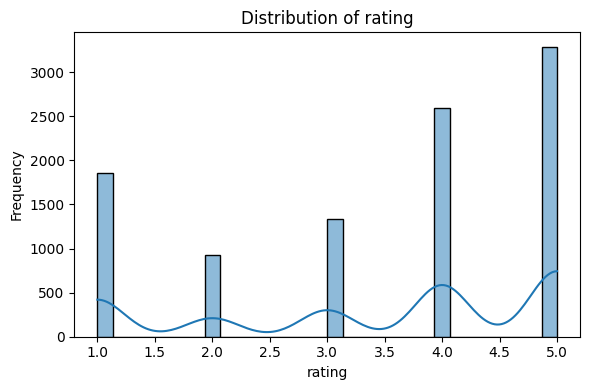

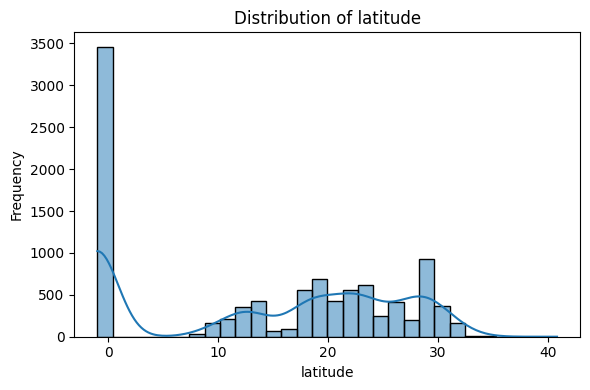

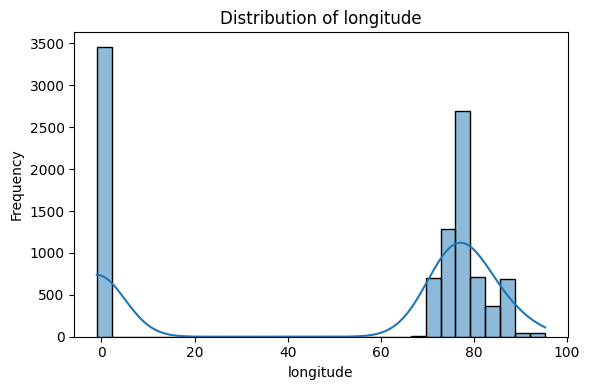

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols_eda = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols_eda:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

### 4.2 Distribution of target variable — Rating

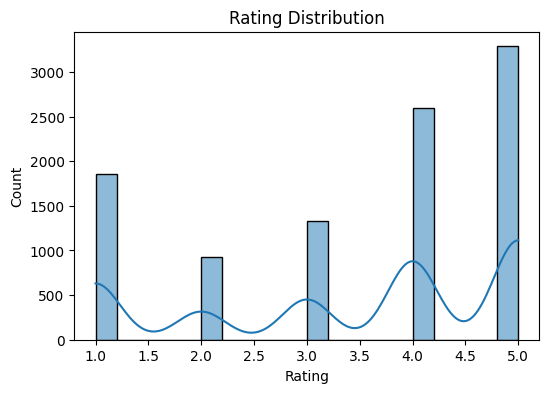

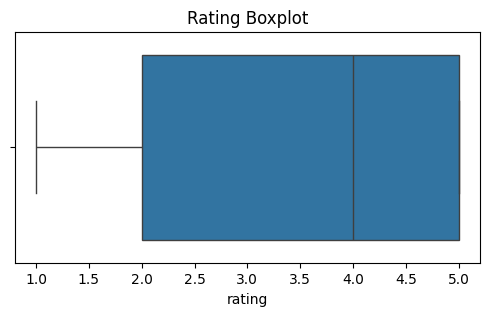

In [ ]:
plt.figure(figsize=(6, 4))
sns.histplot(df['rating'], kde=True, bins=20)
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.show()

plt.figure(figsize=(6, 3))
sns.boxplot(x=df['rating'])
plt.title('Rating Boxplot')
plt.show()

### 4.3 Operator distribution (pie chart)

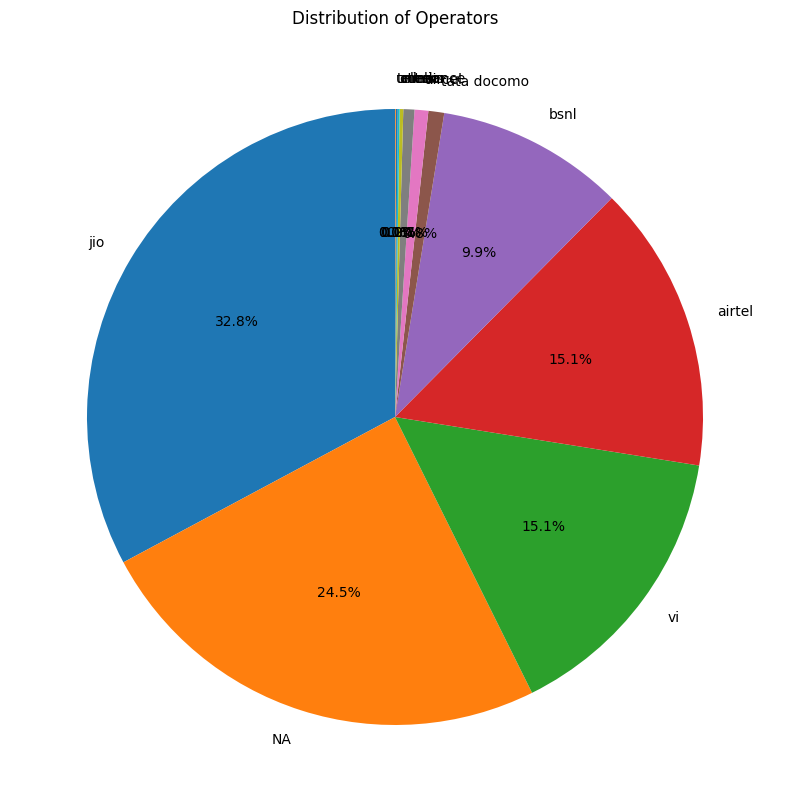

In [ ]:
plt.figure(figsize=(10, 10))
operator_counts = df['operator'].value_counts()
plt.pie(operator_counts, labels=operator_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Operators')
plt.show()

### 4.4 Frequency distribution of categorical features

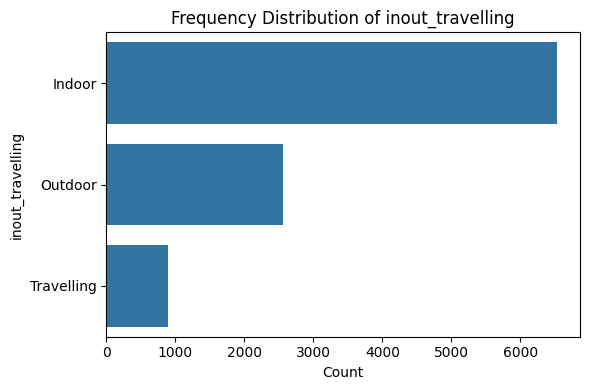

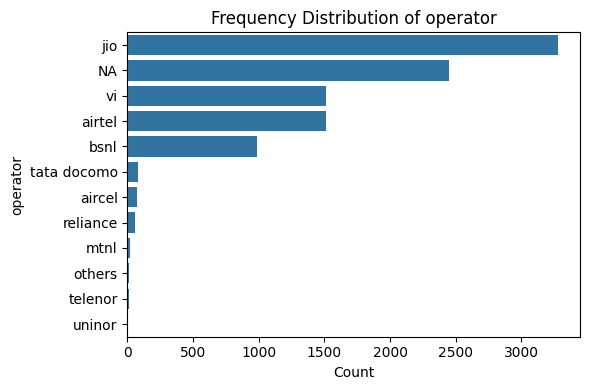

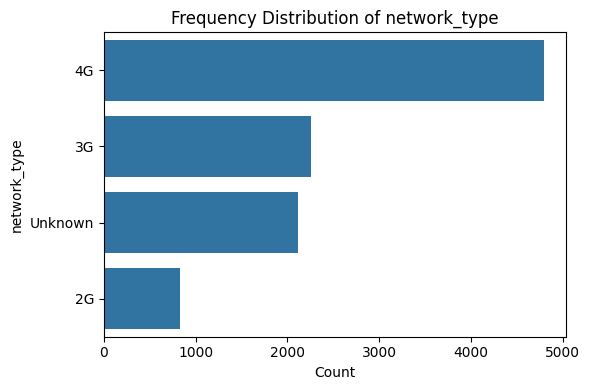

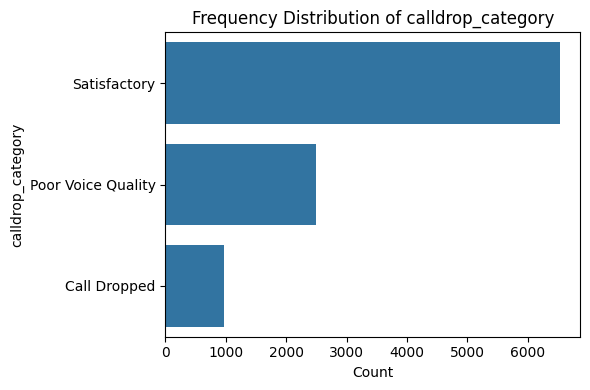

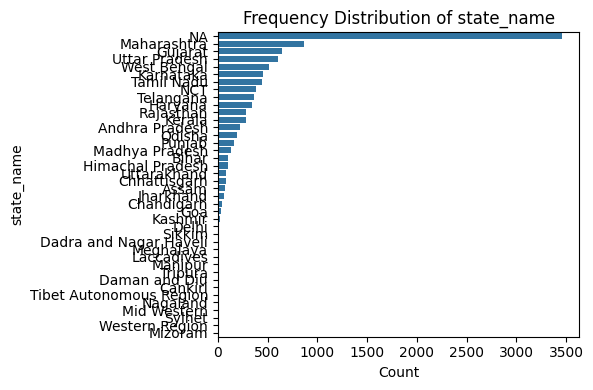

In [ ]:
cat_cols_eda = df.select_dtypes(include='object').columns

for col in cat_cols_eda:
    plt.figure(figsize=(6, 4))
    sns.countplot(y=df[col], order=df[col].value_counts().index)
    plt.title(f'Frequency Distribution of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

### 4.5 Boxplots of numerical features

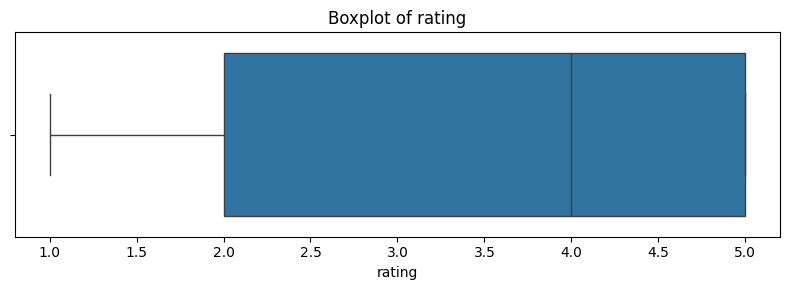

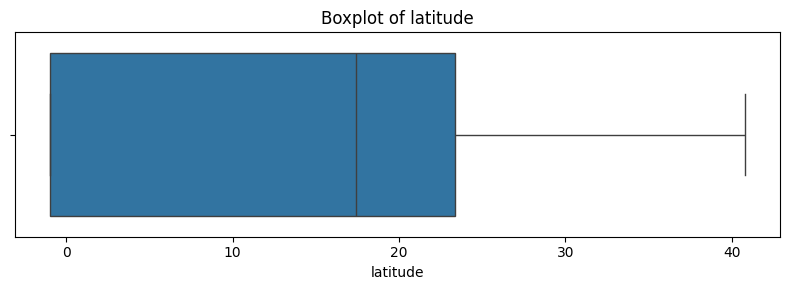

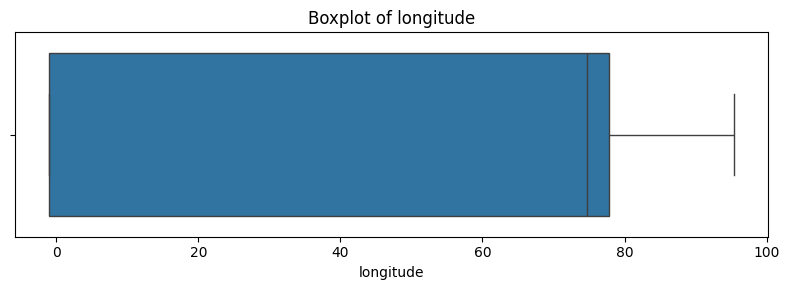

In [ ]:
for col in num_cols_eda:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()

### 4.6 Outlier detection using IQR

In [ ]:
Q1  = df[num_cols_eda].quantile(0.25)
Q3  = df[num_cols_eda].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df[num_cols_eda] < (Q1 - 1.5*IQR)) |
            (df[num_cols_eda] > (Q3 + 1.5*IQR))).sum()

print(outliers)

rating       0
latitude     0
longitude    0
dtype: int64


**Inference:** No outliers detected in any numerical column.

### 4.7 Bivariate analysis — scatter plots

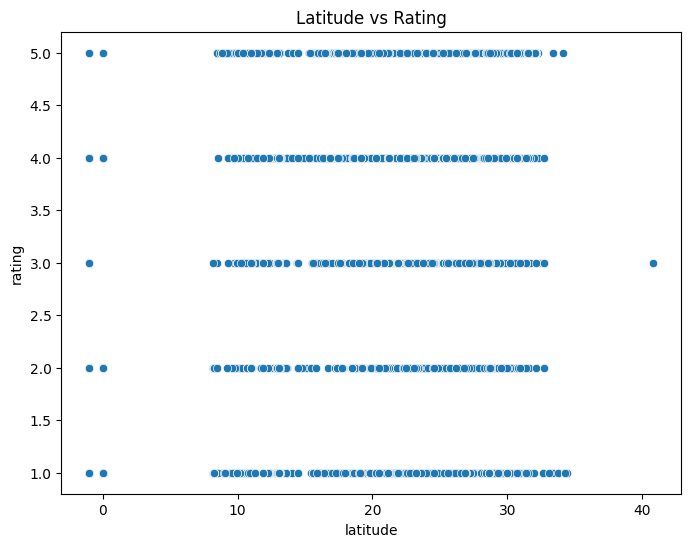

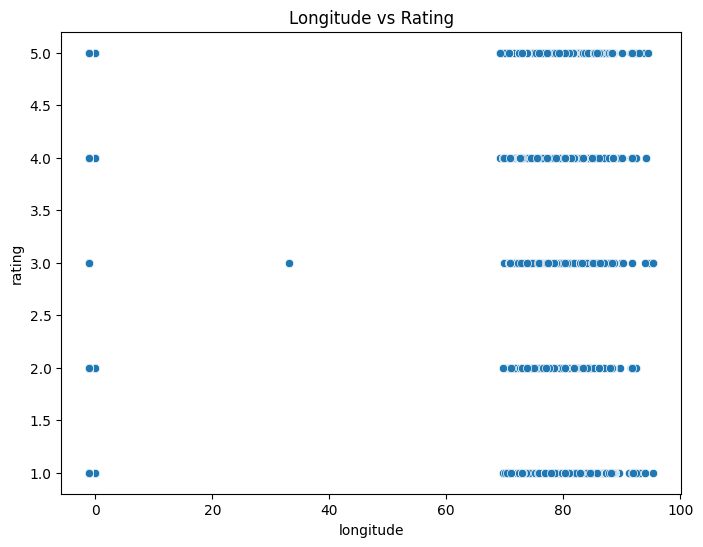

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='latitude', y='rating', data=df)
plt.title('Latitude vs Rating')
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(x='longitude', y='rating', data=df)
plt.title('Longitude vs Rating')
plt.show()

### 4.8 Mean rating by operator and network type

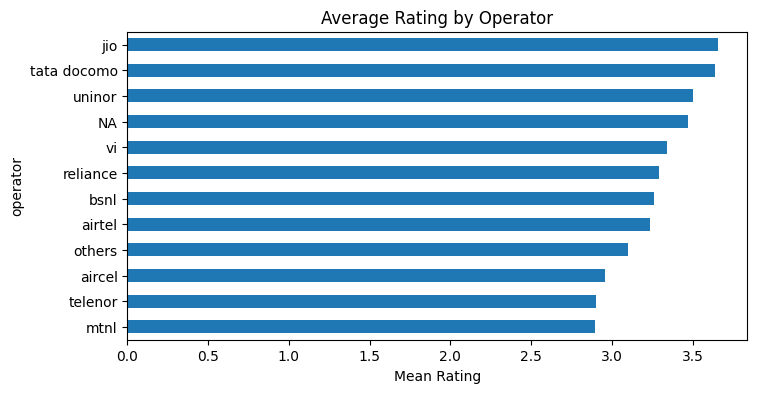

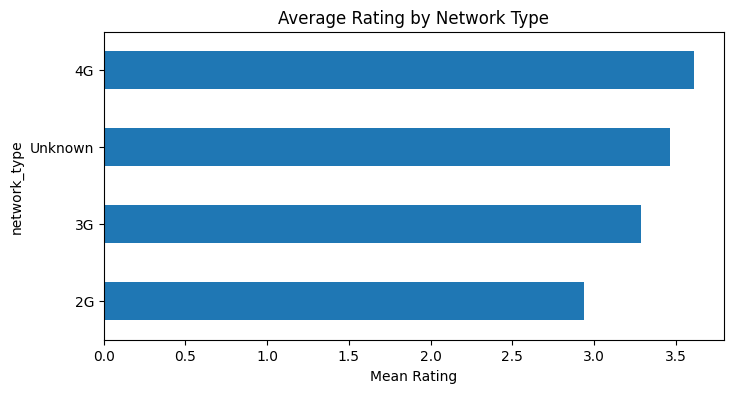

In [ ]:
df.groupby('operator')['rating'].mean().sort_values().plot(kind='barh', figsize=(8, 4))
plt.xlabel('Mean Rating')
plt.title('Average Rating by Operator')
plt.show()

df.groupby('network_type')['rating'].mean().sort_values().plot(kind='barh', figsize=(8, 4))
plt.xlabel('Mean Rating')
plt.title('Average Rating by Network Type')
plt.show()

### 4.9 Geographical distribution of calls

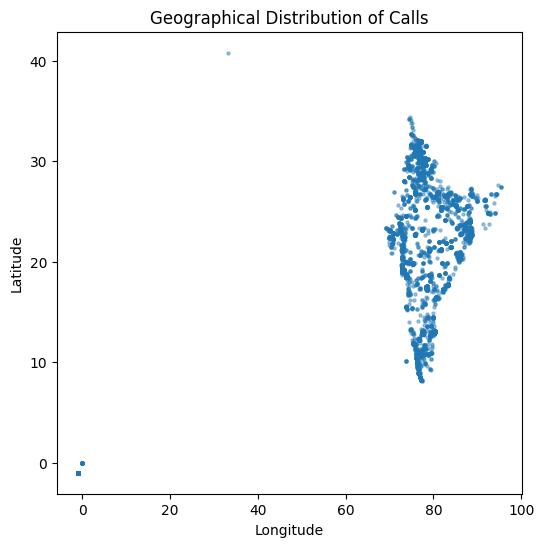

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(df['longitude'], df['latitude'], alpha=0.4, s=5)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographical Distribution of Calls')
plt.show()

### 4.10 Chi-square test — Calldrop category vs State name

- **H₀:** Calldrop category is independent of state name
- **H₁:** Calldrop category is not independent of state name

In [ ]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df['state_name'], df['calldrop_category'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f'Chi-square statistic : {chi2:.4f}')
print(f'p-value              : {p_value:.4e}')
print(f'Degrees of freedom   : {dof}')
print()
alpha = 0.05
if p_value < alpha:
    print(f'p-value ({p_value:.2e}) < alpha ({alpha}) => REJECT H0')
    print('Calldrop category and state name are NOT independent.')
else:
    print(f'p-value ({p_value:.2e}) >= alpha ({alpha}) => FAIL TO REJECT H0')

Chi-square statistic : 339.8666
p-value              : 2.1876e-34
Degrees of freedom   : 78

p-value (2.19e-34) < alpha (0.05) => REJECT H0
Calldrop category and state name are NOT independent.


### 4.11 Correlation heatmap — numerical features

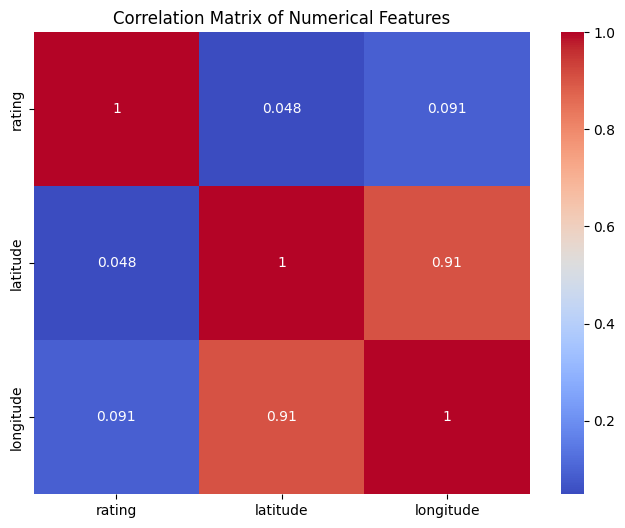

In [ ]:
num_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(8, 6))
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

**Inference:** Latitude and longitude show high correlation (~0.87). This motivates reducing them to a single PCA component rather than keeping both.

---
## SECTION 5 — TRAIN / VALIDATION / TEST SPLIT
> **Critical:** The split happens here — before any encoder, scaler, or PCA is fitted.


In [ ]:
from sklearn.model_selection import train_test_split

# 60% train | 20% validation | 20% test
df_trainval, df_test = train_test_split(df, test_size=0.20, random_state=42)
df_train,    df_val  = train_test_split(df_trainval, test_size=0.25, random_state=42)

df_train = df_train.copy()
df_val   = df_val.copy()
df_test  = df_test.copy()

print(f'Train      : {len(df_train):>5} rows  ({100*len(df_train)/len(df):.0f}%)')
print(f'Validation : {len(df_val):>5} rows  ({100*len(df_val)/len(df):.0f}%)')
print(f'Test       : {len(df_test):>5} rows  ({100*len(df_test)/len(df):.0f}%)')

Train      :  6000 rows  (60%)
Validation :  2000 rows  (20%)
Test       :  2000 rows  (20%)


---
## SECTION 6 — FEATURE ENGINEERING
> All transformers are fitted on training data only, then applied to val and test.

### 6.1 Geo PCA — reduce latitude and longitude to 1 component

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Fit scaler and PCA on training rows only
geo_scaler = StandardScaler()
pca        = PCA(n_components=1)

geo_train = geo_scaler.fit_transform(df_train[['latitude', 'longitude']])
geo_val   = geo_scaler.transform(df_val[['latitude', 'longitude']])
geo_test  = geo_scaler.transform(df_test[['latitude', 'longitude']])

df_train['geo_pca'] = pca.fit_transform(geo_train)
df_val['geo_pca']   = pca.transform(geo_val)
df_test['geo_pca']  = pca.transform(geo_test)

print(f'PCA explained variance (fit on train only): {pca.explained_variance_ratio_[0]:.4f}')

for split in [df_train, df_val, df_test]:
    split.drop(columns=['latitude', 'longitude'], inplace=True)

PCA explained variance (fit on train only): 0.9513


### 6.2 Geo region — rule-based mapping from state name


In [ ]:
north   = ['Punjab','Haryana','Uttar Pradesh','Uttarakhand','Himachal Pradesh','Delhi','NCT','Chandigarh','Kashmir']
south   = ['Tamil Nadu','Kerala','Karnataka','Andhra Pradesh','Telangana']
east    = ['West Bengal','Odisha','Bihar','Jharkhand','Assam','Tripura','Sikkim','Meghalaya','Manipur','Nagaland','Mizoram']
west    = ['Maharashtra','Gujarat','Goa','Rajasthan','Daman and Diu','Dadra and Nagar Haveli']
central = ['Madhya Pradesh','Chhattisgarh']

def map_geo_region(state):
    if state in north:   return 'North'
    if state in south:   return 'South'
    if state in east:    return 'East'
    if state in west:    return 'West'
    if state in central: return 'Central'
    return 'Other'

for split in [df_train, df_val, df_test]:
    split['geo_region'] = split['state_name'].apply(map_geo_region)
    split.drop(columns=['state_name'], inplace=True)

print('Geo region distribution (train):')
print(df_train['geo_region'].value_counts())

Geo region distribution (train):
geo_region
Other      2069
West       1091
South      1082
North      1055
East        581
Central     122
Name: count, dtype: int64


### 6.3 Ordinal encoding — calldrop_category
> Using OrdinalEncoder with an explicit semantic ordering rather than LabelEncoder's arbitrary alphabetical assignment.
> Fitted on training data only.

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

calldrop_order = [['Call Dropped', 'Poor Voice Quality', 'Satisfactory']]
ord_enc = OrdinalEncoder(categories=calldrop_order)

df_train['calldrop_category'] = ord_enc.fit_transform(df_train[['calldrop_category']]).astype(int)
df_val['calldrop_category']   = ord_enc.transform(df_val[['calldrop_category']]).astype(int)
df_test['calldrop_category']  = ord_enc.transform(df_test[['calldrop_category']]).astype(int)

print('calldrop_category encoded: 0=Call Dropped | 1=Poor Voice Quality | 2=Satisfactory')
print(df_train['calldrop_category'].value_counts().sort_index())

calldrop_category encoded: 0=Call Dropped | 1=Poor Voice Quality | 2=Satisfactory
calldrop_category
0     580
1    1474
2    3946
Name: count, dtype: int64


### 6.4 One-hot encoding — nominal categoricals

In [ ]:
# Check low-frequency operators on TRAINING data only
op_freqs      = df_train['operator'].value_counts(normalize=True)
low_freq_ops  = op_freqs[op_freqs < 0.01].index.tolist()
print(f'Low-frequency operators (< 1% of training data): {low_freq_ops}')

for split in [df_train, df_val, df_test]:
    split['operator'] = split['operator'].apply(lambda x: 'other_op' if x in low_freq_ops else x)

ohe_cols = ['network_type', 'inout_travelling', 'operator', 'geo_region']

df_train = pd.get_dummies(df_train, columns=ohe_cols, drop_first=False)
df_val   = pd.get_dummies(df_val,   columns=ohe_cols, drop_first=False)
df_test  = pd.get_dummies(df_test,  columns=ohe_cols, drop_first=False)

# Align val and test to exactly match train's column set
train_feature_cols = [c for c in df_train.columns if c != 'rating']
df_val  = df_val.reindex(columns=train_feature_cols + ['rating'], fill_value=0)
df_test = df_test.reindex(columns=train_feature_cols + ['rating'], fill_value=0)

# Convert bool to int
for split in [df_train, df_val, df_test]:
    bool_cols = split.select_dtypes(include='bool').columns
    split[bool_cols] = split[bool_cols].astype(int)

print(f'Final feature count : {len(train_feature_cols)}')
print(f'Train : {df_train.shape} | Val : {df_val.shape} | Test : {df_test.shape}')

Low-frequency operators (< 1% of training data): ['tata docomo', 'aircel', 'reliance', 'mtnl', 'others', 'telenor', 'uninor']
Final feature count : 21
Train : (6000, 22) | Val : (2000, 22) | Test : (2000, 22)


### 6.5 Post-encoding correlation heatmap

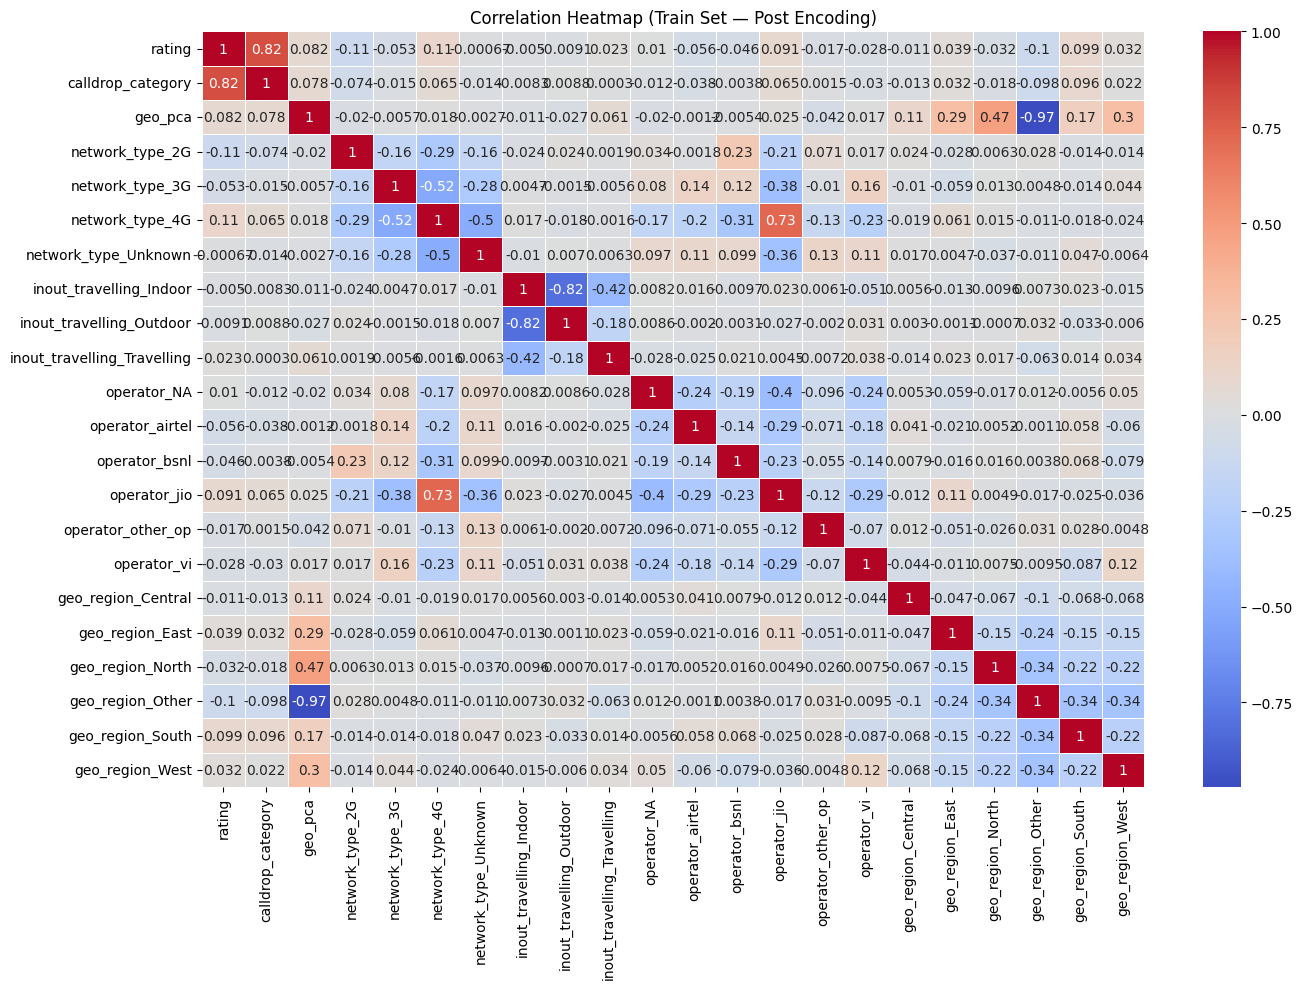

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))
sns.heatmap(df_train.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap (Train Set — Post Encoding)')
plt.tight_layout()
plt.show()

---
## SECTION 7 — DEFINE X / y SPLITS

In [ ]:
feature_cols = [c for c in df_train.columns if c != 'rating']

X_train = df_train[feature_cols].values
y_train = df_train['rating'].values

X_val   = df_val[feature_cols].values
y_val   = df_val['rating'].values

X_test  = df_test[feature_cols].values
y_test  = df_test['rating'].values

print(f'X_train : {X_train.shape} | y_train : {y_train.shape}')
print(f'X_val   : {X_val.shape}   | y_val   : {y_val.shape}')
print(f'X_test  : {X_test.shape}  | y_test  : {y_test.shape}')

print('\nSample features (first row):')
print(dict(zip(feature_cols, X_train[0])))

X_train : (6000, 21) | y_train : (6000,)
X_val   : (2000, 21)   | y_val   : (2000,)
X_test  : (2000, 21)  | y_test  : (2000,)

Sample features (first row):
{'calldrop_category': np.float64(0.0), 'geo_pca': np.float64(-1.8586070507238561), 'network_type_2G': np.float64(0.0), 'network_type_3G': np.float64(0.0), 'network_type_4G': np.float64(0.0), 'network_type_Unknown': np.float64(1.0), 'inout_travelling_Indoor': np.float64(1.0), 'inout_travelling_Outdoor': np.float64(0.0), 'inout_travelling_Travelling': np.float64(0.0), 'operator_NA': np.float64(1.0), 'operator_airtel': np.float64(0.0), 'operator_bsnl': np.float64(0.0), 'operator_jio': np.float64(0.0), 'operator_other_op': np.float64(0.0), 'operator_vi': np.float64(0.0), 'geo_region_Central': np.float64(0.0), 'geo_region_East': np.float64(0.0), 'geo_region_North': np.float64(0.0), 'geo_region_Other': np.float64(1.0), 'geo_region_South': np.float64(0.0), 'geo_region_West': np.float64(0.0)}


---
## SECTION 8 — RANDOM FOREST BASELINE


In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_val_preds = rf.predict(X_val)

rf_val_rmse = np.sqrt(mean_squared_error(y_val, rf_val_preds))
rf_val_mae  = mean_absolute_error(y_val, rf_val_preds)
rf_val_r2   = r2_score(y_val, rf_val_preds)

print('Random Forest — Validation Set')
print(f'  RMSE : {rf_val_rmse:.4f}')
print(f'  MAE  : {rf_val_mae:.4f}')
print(f'  R²   : {rf_val_r2:.4f}')

cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
cv_rmse   = np.sqrt(-cv_scores).mean()
print(f'  5-Fold CV RMSE (train): {cv_rmse:.4f}')

Random Forest — Validation Set
  RMSE : 0.7006
  MAE  : 0.6054
  R²   : 0.7725
  5-Fold CV RMSE (train): 0.7000


---
## SECTION 9 — COMPUTE RESIDUALS ON TRAINING SET
> The FT-Transformer will learn to correct these errors.
> Residuals are computed from in-sample RF predictions

In [ ]:
import torch

# In-sample RF predictions on training set — used as residual targets for FT-Transformer
rf_train_preds  = rf.predict(X_train)
train_residuals = y_train - rf_train_preds

# Val-set residuals — used to monitor FT-T validation loss during training
rf_val_preds_np  = rf.predict(X_val)
val_residuals    = y_val - rf_val_preds_np

print(f'Train residuals — mean: {train_residuals.mean():.4f} | std: {train_residuals.std():.4f}')
print(f'Val   residuals — mean: {val_residuals.mean():.4f} | std: {val_residuals.std():.4f}')

# Convert to tensors
rf_val_preds_t = torch.tensor(rf_val_preds_np, dtype=torch.float32).view(-1, 1)
y_val_t        = torch.tensor(y_val,           dtype=torch.float32).view(-1, 1)
val_res_t      = torch.tensor(val_residuals,   dtype=torch.float32).view(-1, 1)

Train residuals — mean: -0.0001 | std: 0.6512
Val   residuals — mean: 0.0018 | std: 0.7006


---
## SECTION 10 — PREPARE TENSORS FOR FT-TRANSFORMER
> The FT-Transformer uses original categorical columns as embedding indices (integer-encoded),
> and standardised latitude/longitude as numeric inputs.
> All fitting is on training rows only.

In [ ]:
from sklearn.preprocessing import LabelEncoder

NUM_COLS = ['latitude', 'longitude']
CAT_COLS = ['operator', 'inout_travelling', 'network_type', 'calldrop_category', 'state_name']
TARGET   = 'rating'

# Reload the raw (pre-OHE) splits using the same indices as Section 5
# We need integer indices for embeddings, not one-hot columns
raw_train = df.loc[df_train.index].copy() if hasattr(df_train, 'index') else None

# Safer: re-split from the original df using the same seed
raw_trainval, raw_test = train_test_split(df, test_size=0.20, random_state=42)
raw_train, raw_val     = train_test_split(raw_trainval, test_size=0.25, random_state=42)

for split in [raw_train, raw_val, raw_test]:
    split['latitude']  = pd.to_numeric(split['latitude'],  errors='coerce')
    split['longitude'] = pd.to_numeric(split['longitude'], errors='coerce')
    split['rating']    = pd.to_numeric(split['rating'],    errors='coerce')

# Standardise numeric — fit on train only
ft_num_scaler = StandardScaler()
raw_train[NUM_COLS] = ft_num_scaler.fit_transform(raw_train[NUM_COLS])
raw_val[NUM_COLS]   = ft_num_scaler.transform(raw_val[NUM_COLS])
raw_test[NUM_COLS]  = ft_num_scaler.transform(raw_test[NUM_COLS])

# Label-encode categoricals — fit on train only, handle unseen values gracefully
label_encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    raw_train[col] = le.fit_transform(raw_train[col].astype(str))
    known = set(le.classes_)
    max_idx = len(le.classes_)
    for split in [raw_val, raw_test]:
        split[col] = split[col].astype(str).apply(
            lambda x: le.transform([x])[0] if x in known else max_idx
        )
    label_encoders[col] = le

# Cardinalities: +1 to accommodate the unknown category index
cat_cardinalities = [raw_train[col].nunique() + 1 for col in CAT_COLS]

# Build tensors
X_num_train = torch.tensor(raw_train[NUM_COLS].values, dtype=torch.float32)
X_cat_train = torch.tensor(raw_train[CAT_COLS].values, dtype=torch.long)
y_train_t   = torch.tensor(raw_train[TARGET].values,   dtype=torch.float32).view(-1, 1)
res_train_t = torch.tensor(train_residuals,             dtype=torch.float32).view(-1, 1)

X_num_val   = torch.tensor(raw_val[NUM_COLS].values,   dtype=torch.float32)
X_cat_val   = torch.tensor(raw_val[CAT_COLS].values,   dtype=torch.long)

X_num_test  = torch.tensor(raw_test[NUM_COLS].values,  dtype=torch.float32)
X_cat_test  = torch.tensor(raw_test[CAT_COLS].values,  dtype=torch.long)
y_test_t    = torch.tensor(raw_test[TARGET].values,    dtype=torch.float32).view(-1, 1)

print(f'Train tensors — num: {X_num_train.shape} | cat: {X_cat_train.shape} | res: {res_train_t.shape}')
print(f'Cardinalities : {cat_cardinalities}')

Train tensors — num: torch.Size([6000, 2]) | cat: torch.Size([6000, 5]) | res: torch.Size([6000, 1])
Cardinalities : [13, 4, 5, 4, 39]


---
## SECTION 11 — FT-TRANSFORMER ARCHITECTURE

In [ ]:
import torch.nn as nn
import torch.optim as optim

class FTTokenizer(nn.Module):
    """Projects each numeric feature and embeds each categorical feature into a shared token space."""
    def __init__(self, n_numeric, cat_cardinalities, dim):
        super().__init__()
        self.numeric_proj = nn.Parameter(torch.randn(n_numeric, dim))
        self.numeric_bias = nn.Parameter(torch.zeros(n_numeric, dim))
        self.cat_embeddings = nn.ModuleList([
            nn.Embedding(card, dim) for card in cat_cardinalities
        ])

    def forward(self, x_num, x_cat):
        x_num = (x_num - x_num.mean(0)) / (x_num.std(0) + 1e-6)
        x_num = x_num.unsqueeze(-1)
        num_tokens = x_num * self.numeric_proj + self.numeric_bias
        cat_tokens = torch.stack(
            [emb(x_cat[:, i]) for i, emb in enumerate(self.cat_embeddings)], dim=1
        )
        return torch.cat([num_tokens, cat_tokens], dim=1)


class FTTransformer(nn.Module):
    """Transformer encoder with CLS token — used here as a residual corrector."""
    def __init__(self, dim=32, n_heads=4, dropout=0.1):
        super().__init__()
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))
        self.attn = nn.MultiheadAttention(dim, n_heads, batch_first=True, dropout=dropout)
        self.ln1  = nn.LayerNorm(dim)
        self.ln2  = nn.LayerNorm(dim)
        self.ff   = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim * 4, dim)
        )
        self.drop = nn.Dropout(dropout)
        self.head = nn.Linear(dim, 1)

    def forward(self, x):
        B = x.size(0)
        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)
        attn_out, attn_weights = self.attn(x, x, x)
        x = self.ln1(self.drop(attn_out) + x)
        x = self.ln2(self.drop(self.ff(x)) + x)
        return self.head(x[:, 0]), attn_weights


EMBED_DIM = 32
tokenizer = FTTokenizer(n_numeric=len(NUM_COLS), cat_cardinalities=cat_cardinalities, dim=EMBED_DIM)
ft_model  = FTTransformer(dim=EMBED_DIM, n_heads=4, dropout=0.1)

n_params = sum(p.numel() for p in list(tokenizer.parameters()) + list(ft_model.parameters()))
print(f'FT-Transformer total parameters: {n_params:,}')

FT-Transformer total parameters: 14,977


---
## SECTION 12 — TRAIN FT-TRANSFORMER ON RESIDUALS
> The transformer learns to correct the RF's errors on the training set.
> Validation residual loss is monitored each epoch. Early stopping halts training if val loss
> doesn't improve for 20 consecutive epochs.

Epoch 000 | Train Loss: 0.4259 | Val Loss: 0.4854
Epoch 020 | Train Loss: 0.4078 | Val Loss: 0.4791
Early stopping at epoch 36.

Best validation residual MSE: 0.4764


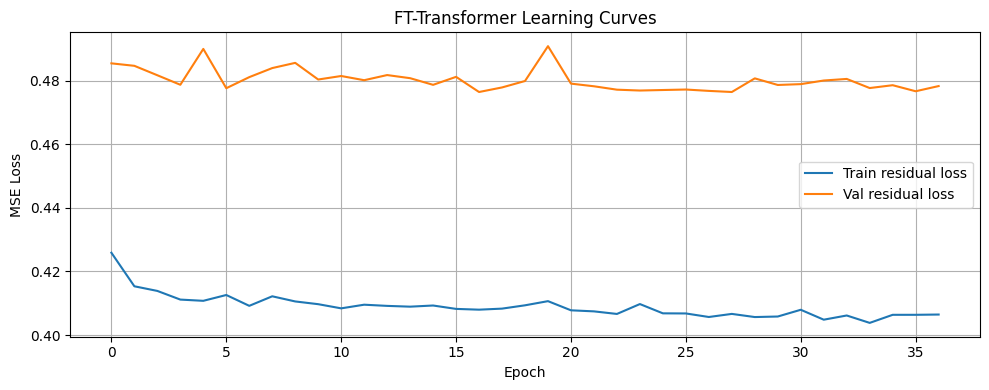

In [ ]:
import matplotlib.pyplot as plt

optimizer = optim.AdamW(
    list(tokenizer.parameters()) + list(ft_model.parameters()),
    lr=1e-3, weight_decay=1e-4
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)
criterion = nn.MSELoss()

def batches(xn, xc, y, bs):
    idx = torch.randperm(xn.size(0))
    for i in range(0, xn.size(0), bs):
        j = idx[i:i+bs]
        yield xn[j], xc[j], y[j]

EPOCHS     = 200
BATCH_SIZE = 64
PATIENCE   = 20

train_losses, val_losses = [], []
best_val_loss  = float('inf')
patience_count = 0
best_state     = None

for epoch in range(EPOCHS):
    # Training pass
    tokenizer.train(); ft_model.train()
    epoch_loss, n_batches = 0, 0
    for xb_num, xb_cat, yb in batches(X_num_train, X_cat_train, res_train_t, BATCH_SIZE):
        optimizer.zero_grad()
        tokens = tokenizer(xb_num, xb_cat)
        preds, _ = ft_model(tokens)
        loss = criterion(preds, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(tokenizer.parameters()) + list(ft_model.parameters()), 1.0
        )
        optimizer.step()
        epoch_loss += loss.item()
        n_batches  += 1
    scheduler.step()
    train_losses.append(epoch_loss / n_batches)

    # Validation pass
    tokenizer.eval(); ft_model.eval()
    with torch.no_grad():
        val_tokens = tokenizer(X_num_val, X_cat_val)
        val_preds_res, _ = ft_model(val_tokens)
        val_loss = criterion(val_preds_res, val_res_t).item()
    val_losses.append(val_loss)

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss  = val_loss
        patience_count = 0
        best_state = {
            'tok': {k: v.clone() for k, v in tokenizer.state_dict().items()},
            'ft':  {k: v.clone() for k, v in ft_model.state_dict().items()}
        }
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f'Early stopping at epoch {epoch}.')
            break

    if epoch % 20 == 0:
        print(f'Epoch {epoch:03d} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_loss:.4f}')

# Restore best weights
tokenizer.load_state_dict(best_state['tok'])
ft_model.load_state_dict(best_state['ft'])
print(f'\nBest validation residual MSE: {best_val_loss:.4f}')

# Learning curve
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train residual loss')
plt.plot(val_losses,   label='Val residual loss')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('FT-Transformer Learning Curves')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

---
## SECTION 12.5 — TRAIN FT-TRANSFORMER STANDALONE (on raw `rating`)
> A fresh FT-Transformer is trained directly on the `rating` target — not on residuals.
> This lets us compare three systems: RF alone, FTT alone, and Fused (RF + FTT on residuals).
> Uses the same architecture, optimiser, and early-stopping settings as Section 12.

Epoch 000 | Train Loss: 2.7012 | Val Loss: 0.5674
Epoch 020 | Train Loss: 0.4855 | Val Loss: 0.5143
Epoch 040 | Train Loss: 0.4759 | Val Loss: 0.5294
Early stopping at epoch 42.

Best standalone FTT validation MSE: 0.5038


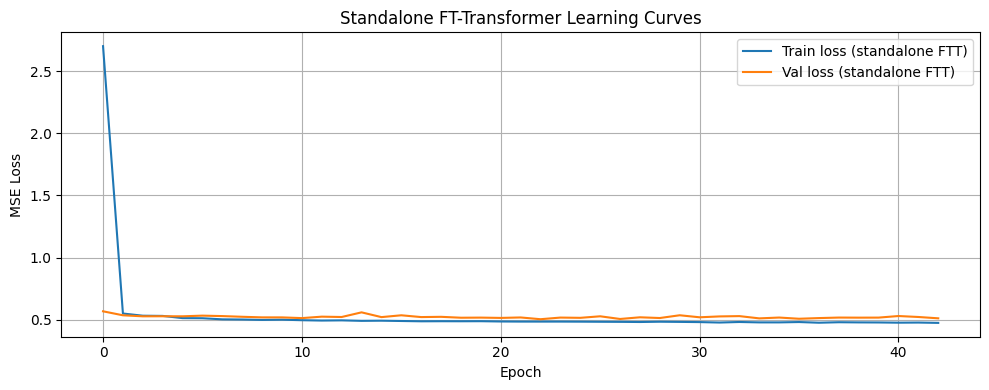

In [ ]:
# ── Standalone FT-Transformer: fresh weights, same architecture ──────────────
tokenizer_solo = FTTokenizer(
    n_numeric=len(NUM_COLS), cat_cardinalities=cat_cardinalities, dim=EMBED_DIM
)
ft_model_solo  = FTTransformer(dim=EMBED_DIM, n_heads=4, dropout=0.1)

optimizer_solo = optim.AdamW(
    list(tokenizer_solo.parameters()) + list(ft_model_solo.parameters()),
    lr=1e-3, weight_decay=1e-4
)
scheduler_solo = optim.lr_scheduler.CosineAnnealingLR(optimizer_solo, T_max=200)
criterion_solo = nn.MSELoss()

# Val targets as tensor
y_val_t_solo = torch.tensor(raw_val[TARGET].values, dtype=torch.float32).view(-1, 1)

train_losses_solo, val_losses_solo = [], []
best_val_loss_solo  = float('inf')
patience_count_solo = 0
best_state_solo     = None

for epoch in range(EPOCHS):
    # Training pass — target is y_train_t (raw rating), not residuals
    tokenizer_solo.train(); ft_model_solo.train()
    epoch_loss, n_batches = 0, 0
    for xb_num, xb_cat, yb in batches(X_num_train, X_cat_train, y_train_t, BATCH_SIZE):
        optimizer_solo.zero_grad()
        tokens = tokenizer_solo(xb_num, xb_cat)
        preds, _ = ft_model_solo(tokens)
        loss = criterion_solo(preds, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(tokenizer_solo.parameters()) + list(ft_model_solo.parameters()), 1.0
        )
        optimizer_solo.step()
        epoch_loss += loss.item()
        n_batches  += 1
    scheduler_solo.step()
    train_losses_solo.append(epoch_loss / n_batches)

    # Validation pass — predict rating directly
    tokenizer_solo.eval(); ft_model_solo.eval()
    with torch.no_grad():
        val_tokens_solo = tokenizer_solo(X_num_val, X_cat_val)
        val_preds_solo, _ = ft_model_solo(val_tokens_solo)
        val_loss_solo = criterion_solo(val_preds_solo, y_val_t_solo).item()
    val_losses_solo.append(val_loss_solo)

    # Early stopping
    if val_loss_solo < best_val_loss_solo:
        best_val_loss_solo  = val_loss_solo
        patience_count_solo = 0
        best_state_solo = {
            'tok': {k: v.clone() for k, v in tokenizer_solo.state_dict().items()},
            'ft':  {k: v.clone() for k, v in ft_model_solo.state_dict().items()}
        }
    else:
        patience_count_solo += 1
        if patience_count_solo >= PATIENCE:
            print(f'Early stopping at epoch {epoch}.')
            break

    if epoch % 20 == 0:
        print(f'Epoch {epoch:03d} | Train Loss: {train_losses_solo[-1]:.4f} | Val Loss: {val_loss_solo:.4f}')

# Restore best weights
tokenizer_solo.load_state_dict(best_state_solo['tok'])
ft_model_solo.load_state_dict(best_state_solo['ft'])
print(f'\nBest standalone FTT validation MSE: {best_val_loss_solo:.4f}')

# Learning curve
plt.figure(figsize=(10, 4))
plt.plot(train_losses_solo, label='Train loss (standalone FTT)')
plt.plot(val_losses_solo,   label='Val loss (standalone FTT)')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('Standalone FT-Transformer Learning Curves')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()


---
## SECTION 13 — ABLATION STUDY
### RF only vs FT-Transformer only vs Fused (RF + FT-Transformer) — evaluated on validation set


ABLATION — Validation Set
Random Forest only                       | RMSE: 0.7006 | MAE: 0.6054 | R²: 0.7725
FT-Transformer only (standalone)         | RMSE: 0.7098 | MAE: 0.6269 | R²: 0.7665
Fused (RF + FT-Transformer)              | RMSE: 0.6902 | MAE: 0.5967 | R²: 0.7792

Fused vs RF alone     — RMSE improvement: 1.48%
Fused vs FTT alone    — RMSE improvement: 2.76%


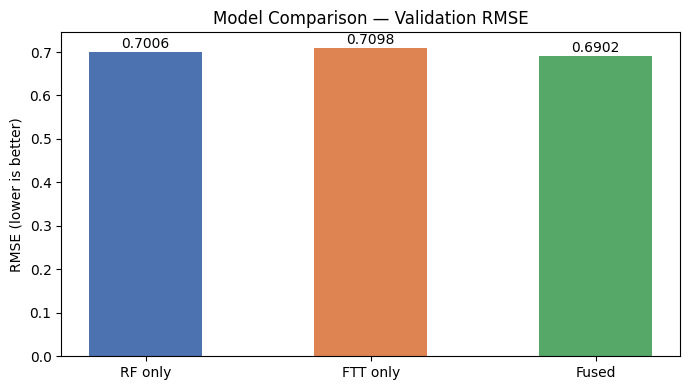

In [ ]:
# ── Fused model val predictions (from Section 12) ────────────────────────────
tokenizer.eval(); ft_model.eval()
with torch.no_grad():
    val_tokens = tokenizer(X_num_val, X_cat_val)
    val_residual_preds, _ = ft_model(val_tokens)

rf_val_t  = torch.tensor(rf_val_preds_np, dtype=torch.float32).view(-1, 1)
fused_val = rf_val_t + val_residual_preds

# ── Standalone FTT val predictions (from Section 12.5) ───────────────────────
tokenizer_solo.eval(); ft_model_solo.eval()
with torch.no_grad():
    val_tokens_solo = tokenizer_solo(X_num_val, X_cat_val)
    ftt_solo_val, _ = ft_model_solo(val_tokens_solo)

# ── Reporting helper ──────────────────────────────────────────────────────────
def report(name, y_true, y_pred):
    yt = y_true.numpy().flatten() if hasattr(y_true, 'numpy') else y_true
    yp = y_pred.detach().numpy().flatten() if hasattr(y_pred, 'detach') else y_pred
    rmse = np.sqrt(mean_squared_error(yt, yp))
    mae  = mean_absolute_error(yt, yp)
    r2   = r2_score(yt, yp)
    print(f'{name:<40} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R\u00b2: {r2:.4f}')
    return rmse, mae, r2

print('=' * 80)
print('ABLATION — Validation Set')
print('=' * 80)
rf_rmse,  *_ = report('Random Forest only',                y_val_t, rf_val_t)
ftt_rmse, *_ = report('FT-Transformer only (standalone)',  y_val_t, ftt_solo_val)
fus_rmse, *_ = report('Fused (RF + FT-Transformer)',       y_val_t, fused_val)
print('=' * 80)
print(f'\nFused vs RF alone     — RMSE improvement: {(rf_rmse  - fus_rmse) / rf_rmse  * 100:.2f}%')
print(f'Fused vs FTT alone    — RMSE improvement: {(ftt_rmse - fus_rmse) / ftt_rmse * 100:.2f}%')

# ── Bar chart comparison ──────────────────────────────────────────────────────
models = ['RF only', 'FTT only', 'Fused']
rmses  = [rf_rmse, ftt_rmse, fus_rmse]
colors = ['#4c72b0', '#dd8452', '#55a868']

plt.figure(figsize=(7, 4))
bars = plt.bar(models, rmses, color=colors, width=0.5)
for bar, val in zip(bars, rmses):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10)
plt.ylabel('RMSE (lower is better)')
plt.title('Model Comparison — Validation RMSE')
plt.tight_layout(); plt.show()


### Residual distribution — validation set (before vs after FT-T correction)

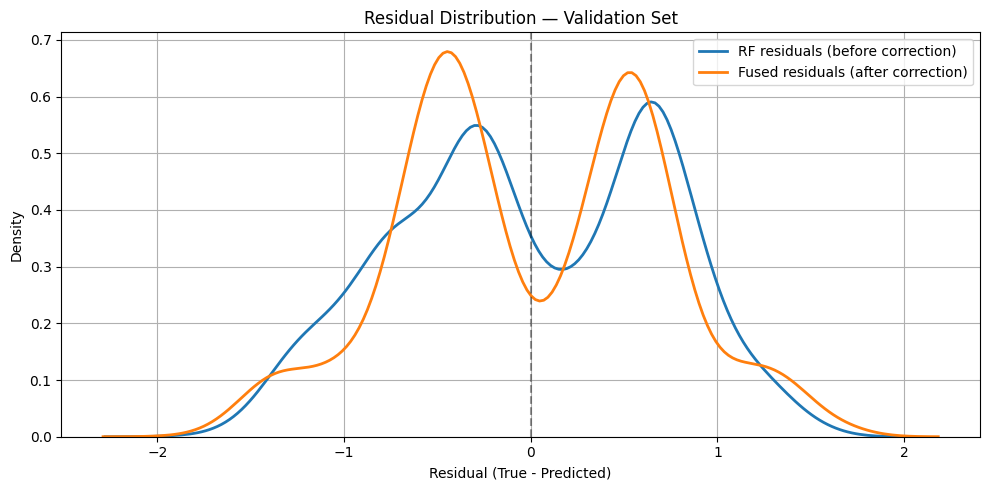

RF residual std   : 0.7008
Fused residual std: 0.6904


In [ ]:
import seaborn as sns

val_res_before = y_val_t - rf_val_t
val_res_after  = y_val_t - fused_val

plt.figure(figsize=(10, 5))
sns.kdeplot(val_res_before.numpy().flatten(), label='RF residuals (before correction)', linewidth=2)
sns.kdeplot(val_res_after.detach().numpy().flatten(), label='Fused residuals (after correction)', linewidth=2)
plt.axvline(0, color='k', linestyle='--', alpha=0.4)
plt.title('Residual Distribution — Validation Set')
plt.xlabel('Residual (True - Predicted)')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

print(f'RF residual std   : {val_res_before.std().item():.4f}')
print(f'Fused residual std: {val_res_after.std().item():.4f}')

---
## SECTION 14 — FINAL EVALUATION ON HELD-OUT TEST SET
>

In [ ]:
tokenizer.eval();      ft_model.eval()
tokenizer_solo.eval(); ft_model_solo.eval()

# RF predictions on test set
rf_test_preds   = rf.predict(X_test)
rf_test_preds_t = torch.tensor(rf_test_preds, dtype=torch.float32).view(-1, 1)

with torch.no_grad():
    # Fused: RF + FTT residual correction
    test_tokens = tokenizer(X_num_test, X_cat_test)
    test_residual_preds, _ = ft_model(test_tokens)
    fused_test_preds = rf_test_preds_t + test_residual_preds

    # Standalone FTT: direct rating prediction
    test_tokens_solo = tokenizer_solo(X_num_test, X_cat_test)
    ftt_solo_test, _ = ft_model_solo(test_tokens_solo)

print('=' * 80)
print('FINAL RESULTS — Test Set (run once)')
print('=' * 80)
report('Random Forest only',                y_test_t, rf_test_preds_t)
report('FT-Transformer only (standalone)',  y_test_t, ftt_solo_test)
report('Fused (RF + FT-Transformer)',       y_test_t, fused_test_preds)
print('=' * 80)


FINAL RESULTS — Test Set (run once)
Random Forest only                       | RMSE: 0.6970 | MAE: 0.6059 | R²: 0.7774
FT-Transformer only (standalone)         | RMSE: 0.7048 | MAE: 0.6246 | R²: 0.7724
Fused (RF + FT-Transformer)              | RMSE: 0.6876 | MAE: 0.5976 | R²: 0.7834


### Prediction vs ground truth — test set

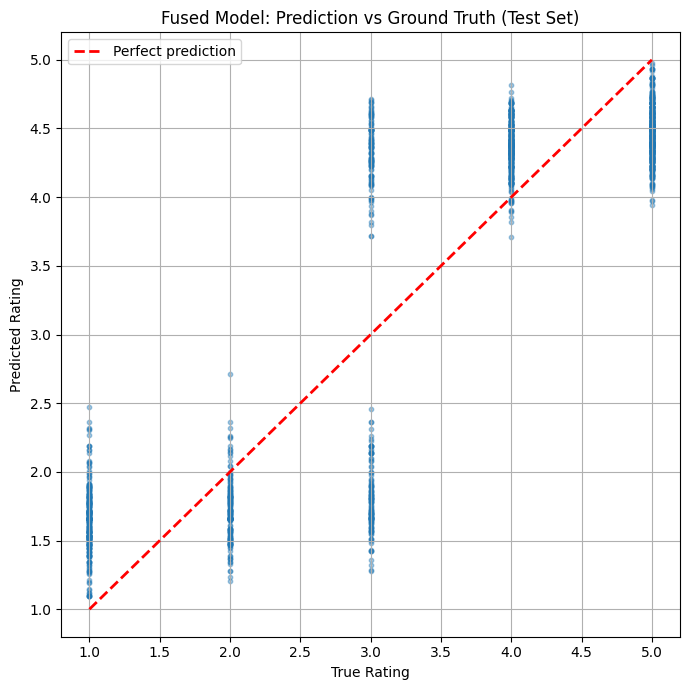

In [ ]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test_t.numpy(), fused_test_preds.detach().numpy(), alpha=0.4, s=10)
mn, mx = float(y_test_t.min()), float(y_test_t.max())
plt.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('True Rating')
plt.ylabel('Predicted Rating')
plt.title('Fused Model: Prediction vs Ground Truth (Test Set)')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

### Residual distribution — test set (before vs after correction)

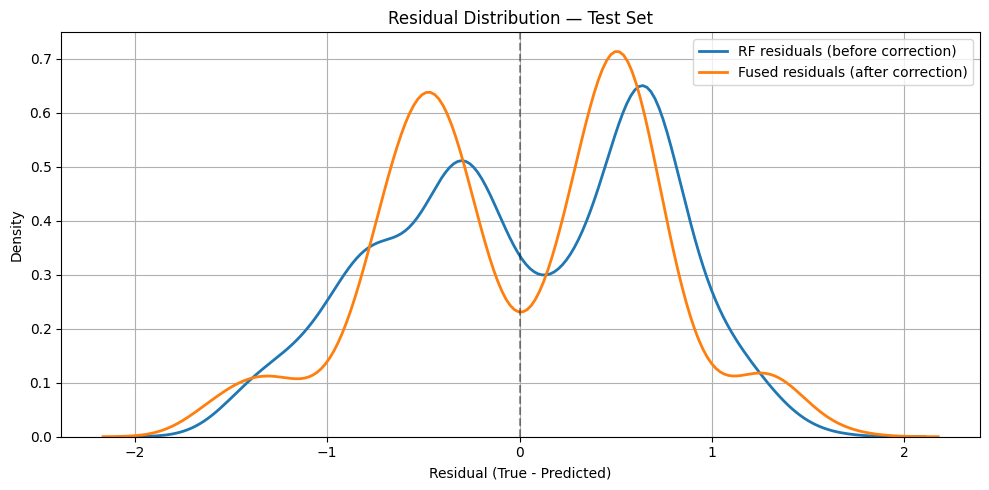

RF residual std   : 0.6968
Fused residual std: 0.6875


In [ ]:
test_res_before = y_test_t - rf_test_preds_t
test_res_after  = y_test_t - fused_test_preds

plt.figure(figsize=(10, 5))
sns.kdeplot(test_res_before.numpy().flatten(),         label='RF residuals (before correction)', linewidth=2)
sns.kdeplot(test_res_after.detach().numpy().flatten(), label='Fused residuals (after correction)', linewidth=2)
plt.axvline(0, color='k', linestyle='--', alpha=0.4)
plt.title('Residual Distribution — Test Set')
plt.xlabel('Residual (True - Predicted)')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

print(f'RF residual std   : {test_res_before.std().item():.4f}')
print(f'Fused residual std: {test_res_after.std().item():.4f}')